In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shwetabh123/mall-customers")

print("Path to dataset files:", path)

100%|██████████| 1.56k/1.56k [00:00<00:00, 1.55MB/s]

Extracting files...
Path to dataset files: C:\Users\yuvab\.cache\kagglehub\datasets\shwetabh123\mall-customers\versions\1


In [11]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\yuvab\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# Core libraries
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import StandardScaler
# K-Means Clustering
from sklearn.cluster import KMeans, MiniBatchKMeans
# Metrics / Evaluation
from sklearn.metrics import silhouette_score
# Optional: Dimensionality reduction (for plotting high-dim data)
from sklearn.decomposition import PCA

In [2]:
path = r"C:\Users\yuvab\.cache\kagglehub\datasets\shwetabh123\mall-customers\versions\1\Mall_Customers.csv"
data = pd.read_csv(path)
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Selecting relevant features
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

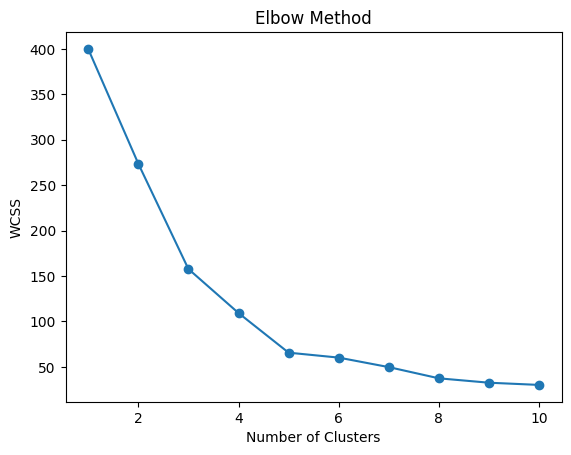

In [4]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Graph
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [5]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, y_kmeans)
print("Silhouette Score:", score)

Silhouette Score: 0.5546571631111091


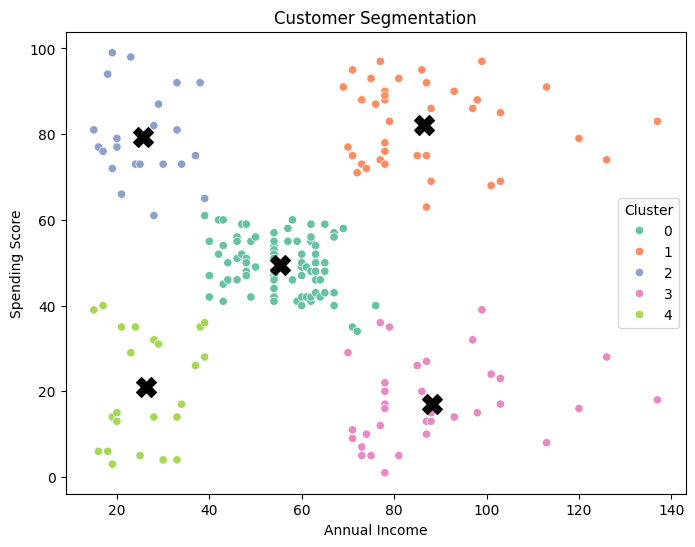

In [7]:
data['Cluster'] = y_kmeans
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=data['Annual Income (k$)'],
    y=data['Spending Score (1-100)'],
    hue=data['Cluster'],
    palette='Set2'
)

# Plot centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0], centroids[:,1], s=200, c='black', marker='X')

plt.title("Customer Segmentation")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

